In [8]:
import numpy as np
from astropy.coordinates import EarthLocation, AltAz, ITRS
from astropy.time import Time
import astropy.units as u
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from geopy.distance import geodesic
# -------------------------------
# CONSTANTS
# -------------------------------
c = 3e8
k = 1.38e-23
T_sys = 100

mpl.rcParams['xtick.labelsize'] = 18

# Alternatively, set all font sizes at once
#plt.rc('font', size=18) 
# -------------------------------
# RADAR PARAMETERS (given)
# -------------------------------
radar = {
    "lat": 29.4,
    "lon": 79.5,
    "height": 1793,
    "freq": 206.5e6,
    "bandwidth": 5e6,
    "Pt": 235e3,
    "gain_dBi": 34
}

lam = c / radar["freq"]
G = 10**(radar["gain_dBi"]/10)

#Gt_dBi = 34   # transmitter gain (given radar)
Gr_dBi = 15   # receiver gain (you can change this)

Gt = G #10**(Gt_dBi/10)
Gr = 10**(Gr_dBi/10)

pulse_widths = [8e-6, 16e-6, 32e-6, 64e-6]
prfs = [250, 1000, 4000, 8000]
integration_times = [0.01, 0.1, 1.0]

ranges = [300e3, 500e3, 1000e3]

# -------------------------------
# UTILITY FUNCTIONS
# -------------------------------
def ecef_from_location(loc, t):
    return loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value

def unit_vector(v):
    return v / np.linalg.norm(v)

# -------------------------------
# GEOMETRY
# -------------------------------
def bistatic_geometry(tx_loc, rx_loc, tgt_loc, t):
    tx = ecef_from_location(tx_loc, t)
    rx = ecef_from_location(rx_loc, t)
    tgt = ecef_from_location(tgt_loc, t)

    Rt_vec = tgt - tx
    Rr_vec = tgt - rx

    Rt = np.linalg.norm(Rt_vec)
    Rr = np.linalg.norm(Rr_vec)

    return Rt, Rr, unit_vector(Rt_vec), unit_vector(Rr_vec)

# -------------------------------
# BISTATIC RADAR EQUATION
# -------------------------------
def received_power_bistatic(Pt, Gt, Gr, lam, sigma, Rt, Rr):
    return (Pt * Gt * Gr * lam**2 * sigma) / ((4*np.pi)**3 * Rt**2 * Rr**2)

# -------------------------------
# PROCESSING
# -------------------------------
def processing_gain(tau, B, PRF, T_int):
    return (tau * B) * (PRF * T_int)

def noise_power(tau):
    B_eff = 1 / tau
    return k * T_sys * B_eff

# -------------------------------
# BISTATIC DOPPLER
# -------------------------------
def bistatic_doppler(v_vec, u_t, u_r, lam):
    return np.dot(v_vec, (u_t + u_r)) / lam

def bistatic_angle(tx_loc, rx_loc, tgt_loc, t):
    """
    Compute bistatic angle (degrees)
    """

    # ECEF vectors
    tx = tx_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value
    rx = rx_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value
    tgt = tgt_loc.get_itrs(obstime=t).cartesian.xyz.to(u.m).value

    # Direction vectors
    Rt_vec = tgt - tx
    Rr_vec = tgt - rx

    u_t = Rt_vec / np.linalg.norm(Rt_vec)
    u_r = Rr_vec / np.linalg.norm(Rr_vec)

    # Bistatic angle
    cos_beta = np.dot(u_t, u_r)
    beta = np.degrees(np.arccos(cos_beta))

    return beta

# -------------------------------
# MAIN
# -------------------------------
t = Time('2026-04-20 00:00:00') #Time.now()

# Tx location (given radar)
tx_loc = EarthLocation(
    lat=radar["lat"]*u.deg,
    lon=radar["lon"]*u.deg,
    height=radar["height"]*u.m
)

    # Example Rx (you can vary)
rx_loc = EarthLocation(
    lat=26.4499*u.deg,
    lon=80.3319*u.deg,
    height=137*u.m
    )

baseline = geodesic((tx_loc.lat.value, tx_loc.lat.value), (rx_loc.lat.value, rx_loc.lon.value)).meters

    # Assume target directly above midpoint at altitude
tgt_lat = tx_loc.lat.value
tgt_lon = tx_loc.lon.value


sigma_test = 1e-3  # 1 mm²

print("=== Bistatic Radar Simulation ===")

for R_alt in ranges:

    tgt_loc = EarthLocation(
        lat=tgt_lat*u.deg,
        lon=tgt_lon*u.deg,
        height=R_alt*u.m
    )

    Rt, Rr, u_t, u_r = bistatic_geometry(tx_loc, rx_loc, tgt_loc, t)

    print(f"\n--- Target altitude: {R_alt/1e3:.0f} km ---")
    print(f"Rt = {Rt/1e3:.1f} km, Rr = {Rr/1e3:.1f} km")

        # assume velocity perpendicular to radial direction
    v_mag = 7500
    v_vec = v_mag * np.array([0, 1, 0])  # arbitrary direction

    fD = bistatic_doppler(v_vec, u_t, u_r, lam)
    print(f"Bistatic Doppler ≈ {fD/1e3:.1f} kHz")

    for tau in pulse_widths:
        for prf in prfs:
            for T_int in integration_times:

                Pr = received_power_bistatic(
                    radar["Pt"], Gt, Gr, lam,
                    sigma_test, Rt, Rr
                    )

                Gp = processing_gain(
                    tau, radar["bandwidth"], prf, T_int
                    )

                Pn = noise_power(tau)

                SNR = (Pr * Gp) / Pn

                print(
                        f"tau={tau*1e6:>5.0f}us | PRF={prf:>5} | "
                        f"T={T_int:.2f}s → SNR={10*np.log10(SNR):6.1f} dB"
                    )

=== Bistatic Radar Simulation ===

--- Target altitude: 300 km ---
Rt = 298.2 km, Rr = 457.0 km
Bistatic Doppler ≈ 5.5 kHz
tau=    8us | PRF=  250 | T=0.01s → SNR=  -2.1 dB
tau=    8us | PRF=  250 | T=0.10s → SNR=   7.9 dB
tau=    8us | PRF=  250 | T=1.00s → SNR=  17.9 dB
tau=    8us | PRF= 1000 | T=0.01s → SNR=   3.9 dB
tau=    8us | PRF= 1000 | T=0.10s → SNR=  13.9 dB
tau=    8us | PRF= 1000 | T=1.00s → SNR=  23.9 dB
tau=    8us | PRF= 4000 | T=0.01s → SNR=  10.0 dB
tau=    8us | PRF= 4000 | T=0.10s → SNR=  20.0 dB
tau=    8us | PRF= 4000 | T=1.00s → SNR=  30.0 dB
tau=    8us | PRF= 8000 | T=0.01s → SNR=  13.0 dB
tau=    8us | PRF= 8000 | T=0.10s → SNR=  23.0 dB
tau=    8us | PRF= 8000 | T=1.00s → SNR=  33.0 dB
tau=   16us | PRF=  250 | T=0.01s → SNR=   3.9 dB
tau=   16us | PRF=  250 | T=0.10s → SNR=  13.9 dB
tau=   16us | PRF=  250 | T=1.00s → SNR=  23.9 dB
tau=   16us | PRF= 1000 | T=0.01s → SNR=  10.0 dB
tau=   16us | PRF= 1000 | T=0.10s → SNR=  20.0 dB
tau=   16us | PRF= 1000 | T

In [9]:
import matplotlib.pyplot as plt

def plot_bistatic_geometry(tx_loc, rx_loc, tgt_loc, t):

    # Get ECEF vectors
    tx = tx_loc.get_itrs(obstime=t).cartesian.xyz.value
    rx = rx_loc.get_itrs(obstime=t).cartesian.xyz.value
    tgt = tgt_loc.get_itrs(obstime=t).cartesian.xyz.value

    # Local ENU at Tx
    lat = tx_loc.lat.rad
    lon = tx_loc.lon.rad

    east = np.array([-np.sin(lon), np.cos(lon), 0])
    north = np.array([
        -np.sin(lat)*np.cos(lon),
        -np.sin(lat)*np.sin(lon),
         np.cos(lat)
    ])

    def azimuth(vec):
        e = np.dot(vec, east)
        n = np.dot(vec, north)
        return np.arctan2(e, n)

    Rr_vec = rx - tx
    Rt_vec = tgt - tx

    az_rx = azimuth(Rr_vec)
    az_tgt = azimuth(Rt_vec)

    # Normalize radius (just for plotting)
    r_rx = 1.0
    #r_tgt = 0.8
    r_tx = 0
    plt.figure(figsize=(10,10))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    #ax.text(0,0,'ASTRAD')
    #ax.text(190,1.2,'IITK Bistatic Rx station')
    ax.scatter(0, 0, label="ASTRAD (Transmitter)", s=500)
    ax.scatter(az_rx, r_rx, label="Kanpur Rx Radar", s=500)
    #ax.scatter(az_tgt, r_tgt, label="Target", s=100)
    ax.set_rticks([])  # Less dense radial ticks
    #ax.set_title("Bistatic Geometry")
    ax.legend(loc="best")
    plt.savefig("4.6.jpeg")
    plt.show()

In [10]:
def array_gain_yagi(num_elements, element_gain_dBi, loss_dB=2):
    G_elem = 10**(element_gain_dBi/10)
    G_array = num_elements * G_elem
    G_array_eff = G_array * 10**(-loss_dB/10)
    return 10*np.log10(G_array_eff), G_array_eff

Gr_dBi, Gr = array_gain_yagi(16, 7, loss_dB=2)

print(f"Receiver gain ≈ {Gr_dBi:.1f} dBi")

Receiver gain ≈ 17.0 dBi


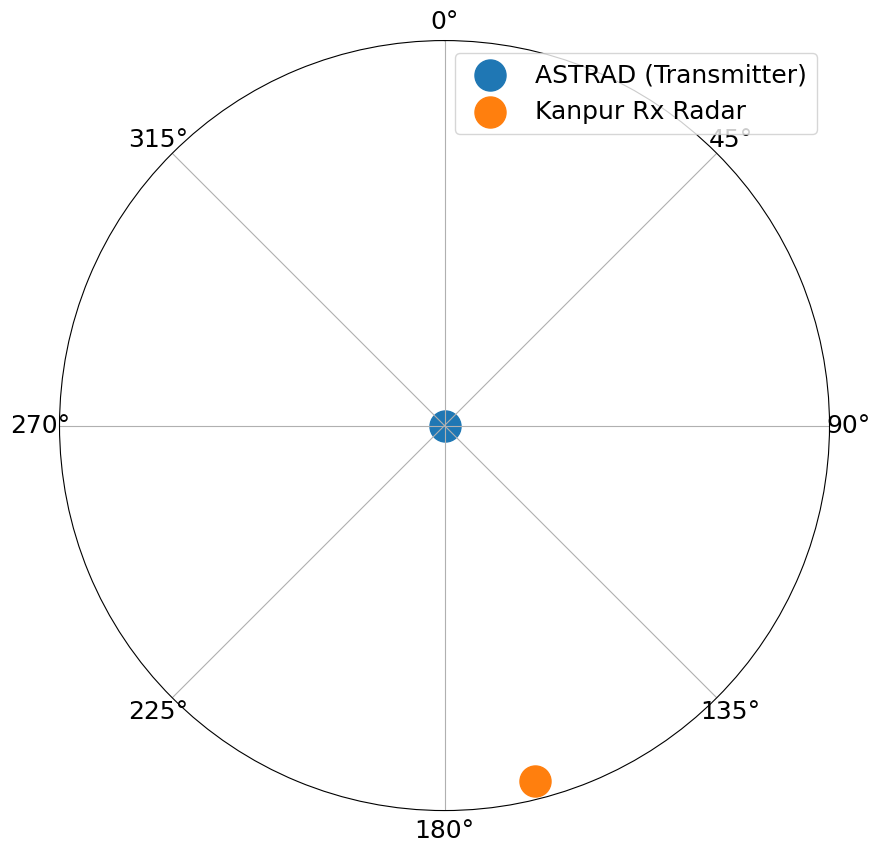

In [11]:
plot_bistatic_geometry(tx_loc=tx_loc,rx_loc=rx_loc,tgt_loc=tgt_loc,t=t)

In [19]:
def plot_snr_vs_prf(Pt, Gt, Gr, lam, sigma, Rt, Rr, tau, B, T_int):

    prfs = np.linspace(100, 10000, 50)
    snr_list = []

    for prf in prfs:
        Pr = received_power_bistatic(Pt, Gt, Gr, lam, sigma, Rt, Rr)
        Gp = (tau * B) * (prf * T_int)
        Pn = noise_power(tau)

        SNR = (Pr * Gp) / Pn
        snr_list.append(10*np.log10(SNR))

    plt.figure()
    plt.semilogx(prfs, snr_list)
    plt.xlabel("PRF (Hz)")
    plt.ylabel("SNR (dB)")
    plt.title("SNR vs PRF")
    plt.grid()
    plt.savefig("4.7.jpeg")
    plt.show()

def plot_snr_vs_tau(Pt, Gt, Gr, lam, sigma, Rt, Rr, prf, B, T_int):

    taus = np.linspace(1e-6, 100e-6, 50)
    snr_list = []

    for tau in taus:
        Pr = received_power_bistatic(Pt, Gt, Gr, lam, sigma, Rt, Rr)
        Gp = (tau * B) * (prf * T_int)
        Pn = noise_power(tau)

        SNR = (Pr * Gp) / Pn
        snr_list.append(10*np.log10(SNR))

    plt.figure()
    plt.plot(taus*1e6, snr_list)
    plt.xlabel("Pulse Width (µs)")
    plt.ylabel("SNR (dB)")
    plt.title("SNR vs Pulse Width")
    plt.grid()
    plt.savefig("4.8.jpeg")
    plt.show()

def plot_snr_vs_rcs(Pt, Gt, Gr, lam, Rt, Rr, tau, prf, B, T_int):

    rcs_vals = np.logspace(-8, 0, 100)  # from 0.01 mm² to 1 m²
    snr_list = []

    for sigma in rcs_vals:
        Pr = received_power_bistatic(Pt, Gt, Gr, lam, sigma, Rt, Rr)
        Gp = (tau * B) * (prf * T_int)
        Pn = noise_power(tau)

        SNR = (Pr * Gp) / Pn
        snr_list.append(10*np.log10(SNR))

    snr_array = np.array(snr_list)

    plt.figure()
    ax = plt.gca()

    ax.semilogx(rcs_vals, snr_array, label="SNR")

    threshold = 10

    # Draw threshold line
    ax.axhline(threshold, linestyle='--', label="10 dB threshold")

    # ✅ Fill entire region below threshold
    ax.axhspan(-50, threshold, alpha=0.3)

    ax.set_xlabel("RCS (m²)",fontsize=18)
    ax.set_ylabel("SNR (dB)",fontsize=18)
    #ax.set_title("SNR vs RCS with Detection Region")
    ax.grid()
    plt.savefig("4.9.jpeg")
    ax.legend()

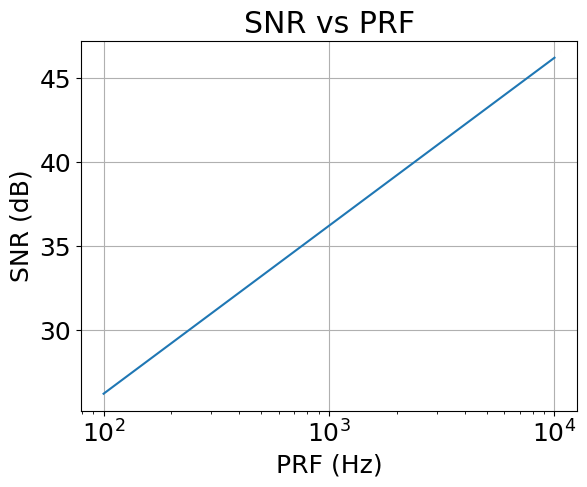

In [20]:
rcs_vals = np.logspace(-8, 0, 100)
sigma = 10**-3
prf = 1e3
plot_snr_vs_prf(radar["Pt"], Gt, Gr, lam, sigma, Rt, Rr, tau, radar["bandwidth"], T_int=0.1)

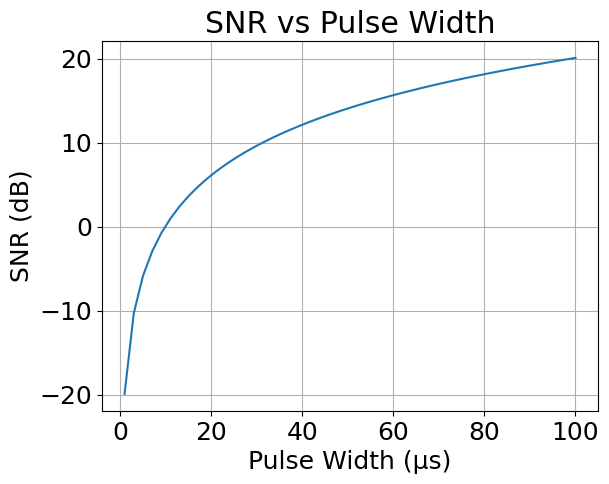

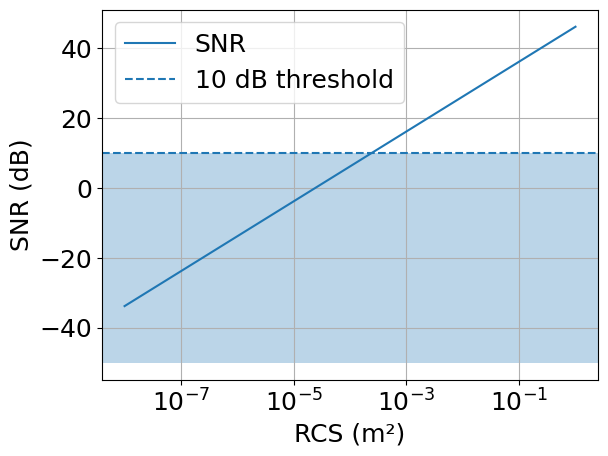

In [7]:
plot_snr_vs_tau(radar["Pt"], Gt, Gr, lam, sigma, Rt, Rr, prf, radar["bandwidth"], T_int=0.1)
plot_snr_vs_rcs(radar['Pt'],Gt,Gr,lam,Rt,Rr,tau,prf,radar['bandwidth'],T_int=0.1)

In [16]:
def debris_rcs_pdf(rcs_vals, mu=-5, sigma=1.5):
    """
    Log-normal PDF in log10 space
    mu: mean log10(RCS)
    sigma: spread
    """

    log_rcs = np.log10(rcs_vals)

    pdf = (1 / (sigma * np.sqrt(2*np.pi))) * \
          np.exp(-0.5 * ((log_rcs - mu)/sigma)**2)

    return pdf

def plot_rcs_pdf():

    rcs_vals = np.logspace(-8, 0, 500)

    pdf = debris_rcs_pdf(rcs_vals)

    plt.figure()
    plt.semilogx(rcs_vals, pdf)

    plt.xlabel("RCS (m²)")
    plt.ylabel("Probability Density")
    plt.title("Space Debris RCS Distribution (Log-normal)")
    plt.grid()
    plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_snr_with_pdf(Pt, Gt, Gr, lam, Rt, Rr, tau, prf, B, T_int):

    rcs_vals = np.logspace(-8, 0, 500)

    # --- Compute SNR ---
    snr_list = []
    for sigma in rcs_vals:
        Pr = received_power_bistatic(Pt, Gt, Gr, lam, sigma, Rt, Rr)
        Gp = (tau * B) * (prf * T_int)
        Pn = noise_power(tau)

        SNR = (Pr * Gp) / Pn
        snr_list.append(10*np.log10(SNR))

    snr_array = np.array(snr_list)

    # --- PDF ---
    pdf = debris_rcs_pdf(rcs_vals)

    # --- Plot ---
    fig, ax1 = plt.subplots()

    # SNR axis (left)
    ax1.semilogx(rcs_vals, snr_array, label="SNR (dB)")
    ax1.set_xlabel("RCS (m²)")
    ax1.set_ylabel("SNR (dB)")
    ax1.set_ylim(0,70)
    ax1.set_xlim(10**-8,10**0)
    ax1.grid()

    # Threshold
    #threshold = 10
    #ax1.axhline(threshold, linestyle='--')
    #ax1.axhspan(ax1.get_ylim()[0], threshold, alpha=0.2)

    ax1.fill_between(rcs_vals, 0, 100,
                     where=(snr_array > 10),
                     alpha=0.2)

    # --- Twin Y axis for PDF ---
    ax2 = ax1.twinx()
    ax2.semilogx(rcs_vals, pdf, linestyle='--', label="PDF")
    ax2.set_ylabel("Probability Density")

    # --- Legends (combine both axes) ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

    #plt.title("SNR vs RCS with Debris Distribution")
    plt.savefig("4.10.jpeg")
    plt.show()

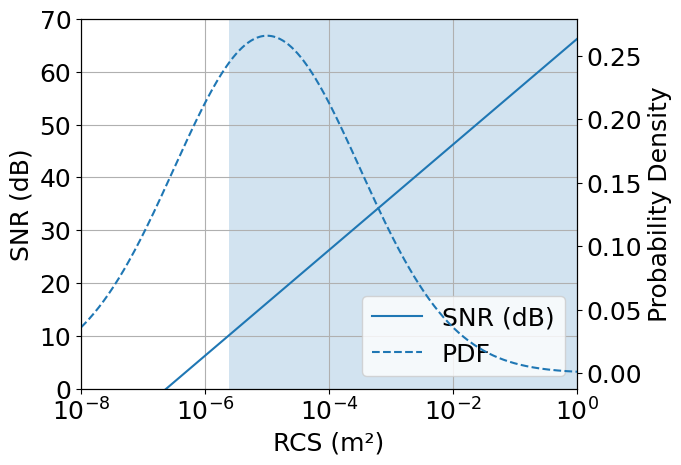

In [18]:
sigma = 10**-3
prf = 1e3
tau = 64*10**-5
plot_snr_with_pdf(radar['Pt'],Gt,Gr,lam,Rt,Rr,tau,prf,radar['bandwidth'],T_int=0.1)

In [44]:
def plot_bistatic_angle_vs_altitude(tx_loc, rx_loc):

    t = Time.now()

    alts = np.linspace(200e3, 1500e3, 50)  # 200–1500 km
    betas = []

    for h in alts:

        tgt_loc = EarthLocation(
            lat=tx_loc.lat,
            lon=tx_loc.lon,
            height=tx_loc.height + h*u.m
        )

        beta = bistatic_angle(tx_loc, rx_loc, tgt_loc, t)
        betas.append(beta)

    plt.figure()
    plt.plot(alts/1e3, betas)

    plt.xlabel("Target altitude (km)")
    plt.ylabel("Bistatic angle (deg)")
    plt.title("Bistatic Angle vs Altitude (Tx–IITK baseline)")
    plt.grid()

    # helpful reference lines
    plt.axhline(90, linestyle='--')
    plt.axhline(180, linestyle='--')
    plt.savefig("4.11.jpeg")
    plt.show()

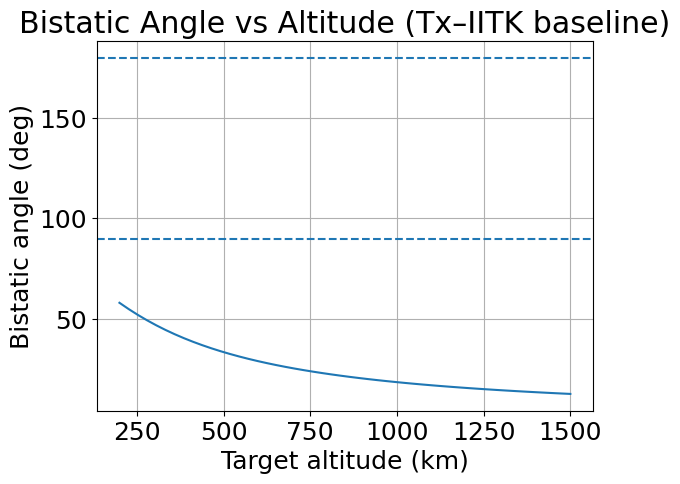

In [45]:
plot_bistatic_angle_vs_altitude(tx_loc,rx_loc)